### seq2seq (sequence-to-sequence)

#### Embedding Vector 준비
1. 영어 glove 임베딩 (사전 학습) 사용
2. 한국어 임베딩 (초기 훈련)

### 학습 데이터 준비

http://www.manythings.org/anki/

1. Encoder 입력 데이터 eng
    - encoder_input_eng 준비 `I love you`
2. Decoder 출력 데이터 kor
    - 학습용 teacher-forcing 모델
        - decoder_input_kor `<sos> 난 널 사랑해`
        - docoder_output_kor `난 널 사랑해 <eos>`
    - 추론용 모델

In [35]:
!gdown 1oEViAatKvMI8JOAgg6gJa8eS3h8Kn53z

Downloading...
From (original): https://drive.google.com/uc?id=1oEViAatKvMI8JOAgg6gJa8eS3h8Kn53z
From (redirected): https://drive.google.com/uc?id=1oEViAatKvMI8JOAgg6gJa8eS3h8Kn53z&confirm=t&uuid=d511500e-205e-4434-9718-dc2f5699952d
To: c:\Users\Playdata\NLP\07_seq2seq\glove.6B.100d.txt

  0%|          | 0.00/347M [00:00<?, ?B/s]
  0%|          | 524k/347M [00:00<01:49, 3.17MB/s]
  1%|          | 3.67M/347M [00:00<00:21, 15.8MB/s]
  3%|▎         | 11.0M/347M [00:00<00:09, 37.2MB/s]
  5%|▍         | 17.3M/347M [00:00<00:07, 46.2MB/s]
  7%|▋         | 23.6M/347M [00:00<00:06, 49.7MB/s]
  9%|▊         | 29.9M/347M [00:00<00:06, 51.7MB/s]
 10%|█         | 36.2M/347M [00:00<00:05, 53.6MB/s]
 12%|█▏        | 41.9M/347M [00:00<00:05, 54.2MB/s]
 14%|█▍        | 48.2M/347M [00:01<00:05, 56.2MB/s]
 16%|█▌        | 54.0M/347M [00:01<00:05, 56.0MB/s]
 17%|█▋        | 59.8M/347M [00:01<00:05, 55.9MB/s]
 19%|█▉        | 66.1M/347M [00:01<00:04, 56.8MB/s]
 21%|██        | 72.9M/347M [00:01<00:04, 57.

In [36]:
!gdown 17-luLRrDsnP_yIzIchd3aCo_WMt4znPF -O eng_kor.txt

Downloading...
From: https://drive.google.com/uc?id=17-luLRrDsnP_yIzIchd3aCo_WMt4znPF
To: c:\Users\Playdata\NLP\07_seq2seq\eng_kor.txt

  0%|          | 0.00/864k [00:00<?, ?B/s]
 61%|██████    | 524k/864k [00:00<00:00, 3.80MB/s]
100%|██████████| 864k/864k [00:00<00:00, 5.19MB/s]


In [37]:
# 데이터 전체
eng_inputs = []  # 영어 원문 리스트
kor_inputs = []  # 한국어 입력 리스트 (디코더 입력 : <sos> 시작토큰 포함)
kor_targets = []  # 한국어 타겟 리스트 (디코더 정답 : <eos> 종료토큰 포함)

with open('eng_kor.txt', 'r', encoding='utf-8') as f:
    for line in f:
        eng, kor, _ = line.split('\t')  # 영어\t한국어\t(기타)

        kor_input = '<sos>' + kor  # 디코더 입력 시작토큰 추가
        kor_target = kor + '<eos>'  # 디코더 타겟 종료토큰 추가

        eng_inputs.append(eng)
        kor_inputs.append(kor_input)
        kor_targets.append(kor_target)

len(eng_inputs), len(kor_inputs), len(kor_targets)  # 문서 길이와 동일 : 5890

(5890, 5890, 5890)

In [38]:
# 2500 ~ 2504 인덱스 정보 확인 (전처리 확인)
print(eng_inputs[2500:2505])
print(kor_inputs[2500:2505])
print(kor_targets[2500:2505])

['I speak French a little.', 'I take back what I said.', 'I tried to make friends.', 'I use this all the time.', 'I use this all the time.']
['<sos>저는 프랑스어를 조금 합니다.', '<sos>아까 한 말 취소야.', '<sos>난 친구를 만드려고 했어.', '<sos>나는 항상 이걸 쓴다.', '<sos>매번 이걸 쓴다.']
['저는 프랑스어를 조금 합니다.<eos>', '아까 한 말 취소야.<eos>', '난 친구를 만드려고 했어.<eos>', '나는 항상 이걸 쓴다.<eos>', '매번 이걸 쓴다.<eos>']


#### 토큰화
- 인코더(영어) : 영문 토크나이저
- 디코더(한글) : 국문 토크나이저

In [39]:
VOCAB_SIZE = 10000  # 사용할 어휘 수 (상위 10000개)

# 영문 토큰화 : 텍스트 -> 정수 시퀀스 변환
from tensorflow.keras.preprocessing.text import Tokenizer

eng_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>')  # 토크나이저 설정 (어휘 수 제한, 미등록 단어 처리)
eng_tokenizer.fit_on_texts(eng_inputs)  # 영어 문장-인덱스 사전 학습(생성)
eng_inputs_seq = eng_tokenizer.texts_to_sequences(eng_inputs)  # 영어 문장 -> 단어 ID 시퀀스 변환

eng_inputs_seq[2500:2505]

[[2, 130, 38, 8, 268],
 [2, 111, 150, 27, 2, 82],
 [2, 300, 4, 213, 202],
 [2, 206, 12, 54, 6, 60],
 [2, 206, 12, 54, 6, 60]]

In [40]:
for seq in eng_inputs_seq[2500:2505]:
    print([eng_tokenizer.index_word[idx] for idx in seq])  # 각 ID를 단어로 역변환(디코딩)해서 확인

['i', 'speak', 'french', 'a', 'little']
['i', 'take', 'back', 'what', 'i', 'said']
['i', 'tried', 'to', 'make', 'friends']
['i', 'use', 'this', 'all', 'the', 'time']
['i', 'use', 'this', 'all', 'the', 'time']


In [41]:
eng_num_words = min(VOCAB_SIZE, len(eng_tokenizer.word_index))  # 실제 사용 어휘 수 (VOCAB_SIZE와 사전 크기 중 작은 값)
eng_max_len = max([len(seq) for seq in eng_inputs_seq])  # 영어 시퀀스 중 가장 긴 문장 토큰 길이 (패딩용 체크)

eng_num_words, eng_max_len

(3200, 101)

국문 토큰화

In [42]:
# 필터 기본값 : '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
kor_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>', filters='')  # 필터 제거
kor_tokenizer.fit_on_texts(kor_inputs + kor_targets)  # 입력 + 타겟 전체로 단어 사전 학습(생성) : <sos>, <eos> 토큰 포함

kor_inputs_seq = kor_tokenizer.texts_to_sequences(kor_inputs)  # 한국어 입력 -> ID 시퀀스
kor_targets_seq = kor_tokenizer.texts_to_sequences(kor_targets)  # 한국어 타겟 -> ID 시퀀스

In [43]:
print(kor_tokenizer.index_word)

{1: '<OOV>', 2: '톰은', 3: '<sos>톰은', 4: '나는', 5: '<sos>나는', 6: '톰이', 7: '수', 8: '난', 9: '<sos>난', 10: '내가', 11: '그', 12: '내', 13: '있어.', 14: '있어.<eos>', 15: '<sos>톰이', 16: '이', 17: '것', 18: '것을', 19: '더', 20: '그는', 21: '할', 22: '있다.', 23: '있다.<eos>', 24: '<sos>그는', 25: '안', 26: '좀', 27: '너무', 28: '네가', 29: '<sos>그', 30: '한', 31: '알고', 32: '<sos>이', 33: '걸', 34: '정말', 35: '있는', 36: '왜', 37: '있어?', 38: '있어?<eos>', 39: '프랑스어를', 40: '<sos>내가', 41: '줄', 42: '네', 43: '우리는', 44: '가장', 45: '하고', 46: '적', 47: '잘', 48: '<sos>우리는', 49: '사람은', 50: '톰을', 51: '우리', 52: '너', 53: '집에', 54: '있을', 55: '건', 56: '그걸', 57: '것은', 58: '<sos>내', 59: '그렇게', 60: '메리가', 61: '<sos>너', 62: '거야.', 63: '않아.', 64: '것이', 65: '없어.', 66: '날', 67: '거야.<eos>', 68: '<sos>네가', 69: '하지', 70: '아주', 71: '적이', 72: '같아.', 73: '않아.<eos>', 74: '같아.<eos>', 75: '없어.<eos>', 76: '그녀는', 77: '아직도', 78: '게', 79: '무슨', 80: '못', 81: '그것을', 82: '좋은', 83: '얼마나', 84: '<sos>그녀는', 85: '어떻게', 86: '여기', 87: '좋아하는', 88: '때', 89: '것이다.', 90: '다', 91

In [44]:
kor_num_words = min(VOCAB_SIZE, len(kor_tokenizer.index_word))  # 실제 사용 어휘 수
kor_max_len = max([len(seq) for seq in kor_inputs_seq])  # 한국어 입력 시퀀스 중 가장 긴 길이

kor_num_words, kor_max_len

(10000, 89)

### 패딩처리
- 인코더 padding='pre'
- 디코더 padding='post'

In [45]:
from tensorflow.keras.preprocessing.sequence import pad_sequences  # 패딩/트런케이팅 함수

# 영어 입력은 최대토큰 길이로 맞추고 앞쪽에 0 패딩 / 한국어는 최대토큰 길이로 맞추고 뒤쪽에 0 패딩
eng_inputs_padded = pad_sequences(eng_inputs_seq, maxlen=eng_max_len, padding='pre')
kor_inputs_padded = pad_sequences(kor_inputs_seq, maxlen=kor_max_len, padding='post')
kor_targets_padded = pad_sequences(kor_targets_seq, maxlen=kor_max_len, padding='pre')

영어 (Encoder 입력) pre 패딩 : 마지막 hidden state 사용. 끝부분이 0으로 끝나지 않고 실제 단어가 오게 함.   
한국어 (Decoder 입력/타겟) post 패딩 : 기본적으로 생성 시 왼쪽 -> 오른쪽 생성(teacher forcing)이 앞에서부터의 시점 정렬이 자연스럽게 되고, 뒤에만 0을 붙여 차후 loss 마스킹/처리에 쉬워짐.

### 모델 생성

encoder + decoder(teacher_forcing) 구조의 모델 생성 및 학습

In [46]:
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for i, vects in enumerate(f):  # 한 줄씩 읽음
        print(vects)
        if i == 3:
            break

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062

, -0.10767 0.11053 0.59812 -0.54361 0.67396 0.10663 0.038867 0.35481 0.06351 -0.094189 0.15786 -0.81665 0.14172 0.21939 0.58505 -0.52158

In [47]:
import numpy as np

# 토크나이저의 단어 인덱스에 맞춰 사전학습 임베딩으로 embedding_matrix를 만드는 함수
def make_embedding_matrix(num_words, embedding_dim, tokenizer, file_path):
    embedding_matrix = np.zeros((num_words+1, embedding_dim))  # (단어수+1, 임베딩차원) 0으로 채움 (0은 

    pretraied_embedding = {}  # 사전학습 임베딩 저장 {word: vector}

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            word, *vects = line.split()  # 첫 번째 토큰은 word, 나머지는 vector 값들
            vects = np.array(vects, dtype=np.float32)  # 문자열 벡터값 -> float32 nd Array 변환
            pretraied_embedding[word] = vects

        for word, index in tokenizer.word_index.items():
            vects_ = pretraied_embedding.get(word)  # 해당 단어의 사전학습 벡터 조회(없으면 None)
            if vects_ is not None:  # 임베딩 존재시
                embedding_matrix[index] = vects_  # 해당 인덱스 위치에 벡터로 수정

        return embedding_matrix  # 만약 사전학습 임베딩에 없는 단어는 0 벡터로 유지

In [48]:
EMBEDDING_DIM = 100  # 사용할 임베딩 차원 (사전학습된 임베딩 차원 100차원)

en_embedding_matrix = make_embedding_matrix(
    eng_num_words,   # 사용할 어휘 수
    EMBEDDING_DIM,   # 임베딩 차원
    eng_tokenizer,   # 영어 토크나이저 (단어 -> 인덱스 사전 보유)
    'glove.6B.100d.txt'  # 임베딩 사전학습 파일 경로
)

en_embedding_matrix.shape  # (eng_num_words +1(패딩), embedding_dim)

(3201, 100)

In [49]:
# 영어 인덱스 -> 단어 리스트 생성(패딩 토큰 추가)
eng_word_index = ['<PAD>'] + list(eng_tokenizer.index_word.values())

print(eng_word_index)

['<PAD>', '<unk>', 'i', 'tom', 'to', 'you', 'the', 'is', 'a', 'that', 'do', 'in', 'this', 'was', 'have', 'he', "i'm", 'my', 'are', 'of', "don't", 'it', 'me', 'be', 'your', 'like', 'for', 'what', 'want', 'think', 'we', 'know', 'not', 'mary', 'his', 'there', 'how', 'can', 'french', 'and', 'very', 'has', "it's", 'at', 'go', 'with', 'she', 'did', "didn't", 'on', 'here', 'why', 'going', 'been', 'all', 'no', 'as', 'really', 'help', 'please', 'time', "can't", 'they', 'will', 'him', "isn't", 'one', "you're", 'if', 'about', 'good', "that's", 'who', 'too', "doesn't", 'up', 'had', 'were', 'where', 'would', 'from', "tom's", 'said', 'need', 'something', 'when', 'us', 'tell', 'never', 'home', 'now', 'still', 'more', 'school', 'so', 'an', 'should', 'come', 'than', 'some', 'sorry', 'but', 'ever', 'get', 'work', 'out', "i'll", "i've", 'three', 'by', 'boston', 'take', 'keep', 'stop', 'just', 'doing', 'thought', 'hard', 'love', 'old', 'many', 'last', 'people', 'right', 'any', 'used', 'say', 'money', 'muc

In [50]:
import pandas as pd 

pd.DataFrame(en_embedding_matrix, index=eng_word_index)  # 행은 index(단어), 열은 임베딩 차원값

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
<PAD>,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
<unk>,0.283650,-0.626300,-0.44351,0.217700,-0.087421,-0.170620,0.292660,-0.024899,0.264140,-0.17023,...,0.138850,-0.228620,0.071792,-0.432080,0.539800,-0.085806,0.032651,0.436780,-0.826070,-0.157010
i,-0.046539,0.619660,0.56647,-0.465840,-1.189000,0.445990,0.066035,0.319100,0.146790,-0.22119,...,-0.323430,-0.431210,0.413920,0.283740,-0.709310,0.150030,-0.215400,-0.376160,-0.032502,0.806200
tom,-0.583880,-0.469400,0.16855,-1.670300,-0.116010,0.048738,-0.342010,-0.376910,-0.953080,-0.88260,...,0.264290,0.337860,0.357910,0.549010,0.006725,0.281580,0.343730,0.137040,0.089572,-0.542770
to,-0.189700,0.050024,0.19084,-0.049184,-0.089737,0.210060,-0.549520,0.098377,-0.201350,0.34241,...,-0.131340,0.058617,-0.318690,-0.614190,-0.623930,-0.415480,-0.038175,-0.398040,0.476470,-0.159830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
whom,0.341680,0.545720,-0.15683,-0.205450,-0.199470,0.389270,-0.017266,-0.244750,0.124760,-0.34392,...,0.142210,-0.556420,0.457640,-0.243960,-1.146800,0.330140,-0.900430,-0.014213,0.161420,-0.444830
intimately,-0.416930,0.131300,0.50615,0.034870,0.255630,0.409070,0.234080,-0.574340,0.293270,0.14061,...,-0.636420,0.066336,-0.449260,-1.350100,0.381640,-0.051961,-0.425590,-0.667450,0.009747,0.061855
millions,0.622040,1.063600,0.13146,-0.203880,0.555570,0.443570,-0.524210,0.040587,0.470640,-0.53788,...,-0.063191,-0.111260,0.666090,-0.972050,-0.558910,-0.837910,-0.147160,0.862920,0.302910,-0.225640
inhabit,-0.927750,0.738860,0.69884,0.138580,0.020592,0.521490,-0.541050,0.501790,0.206630,-0.51982,...,0.491800,-0.235440,0.482430,-0.714400,-0.378190,0.271660,-1.243600,-0.288030,0.065840,0.053163


In [51]:
# seq2seq Encoder 모델 구성 (사전학습 임베딩 + LSTM)
from tensorflow.keras import layers, models  # Kears 레이어/모델 구성 모듈

LATENT_DIM = 512  # LSTM 은닉 상태 차원

encoder_inputs = layers.Input(shape=(eng_max_len,))  # (B, eng_max_len) 형태의 단어 ID
# 사전학습된 임베딩 가중치로 Embedding 레이어 구성
en_embedding_layer = layers.Embedding(eng_num_words+1, EMBEDDING_DIM, weights=[en_embedding_matrix])
x = en_embedding_layer(encoder_inputs)  # (B, eng_max_len) -> (B, eng_max_len, EMBEDDING_DIM) 임베딩 차원 추가
encoder_outputs, h, c = layers.LSTM(LATENT_DIM, return_state=True)(x)   # 마지막 출력, 최종 H(hidden), C(cell state) 반환
encoder_state = [h, c]  # 디코더로 전달할 encoder state 묶어 전달

encoder_model = models.Model(inputs=encoder_inputs, outputs=encoder_state)  # 모델 객체 생성 : Encoder 입력 -> (h, c) 출력
encoder_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 101)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 101, 100)       │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ [(None, 512), (None,   │     1,255,424 │
│                                 │ 512), (None, 512)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,575,524 (6.01 MB)

 Trainable params: 1,575,524 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

### 디코더 모델 (Teacher-Forcing)

In [52]:
# seq2seq Decoder 모델 (Teacher Forcing 학습용)
decoder_inputs = layers.Input(shape=(kor_max_len,))  # (b, kor_max_len) 형태 디코더
ko_embedding_layer = layers.Embedding(kor_num_words+1, EMBEDDING_DIM)  # 한국어 단어 ID -> 임베딩 레이어
x = ko_embedding_layer(decoder_inputs)  # (B, kor_max_len) -> (B, kor_max_len, EMBEDDING_DIM)

# 디코더 LSTM : 시퀀스 전체 출력 + state(h, c) 모두 반환
decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
x, h, c = decoder_lstm(x, initial_state=encoder_state)  # 인코더 출력 state(h, c)를 초기상태로 넣어 디코더 수행

decoder_dense = layers.Dense(kor_num_words+1, activation='softmax')  # 각 시점별로 다음 단어 확률 분포 예측값을 출력 (어휘 크기)
decoder_outputs = decoder_dense(x)  # 소프트맥스 확률 (B, kor_max_len, kor_num_words+1)

decoder_teacher_forcing_model = models.Model(
    inputs = [encoder_inputs, decoder_inputs],  # 입력 : 영어 인코더 입력 + 한국어 디코더 입력
    outputs = decoder_outputs  # 출력 : 한국어 다음 단어 분포(시점별)
)

decoder_teacher_forcing_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 101)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 89)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 101, 100)  │    320,100 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 89, 100)   │  1,000,100 │ input_layer_12[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 512),     │  1,255,424 │ embedding_2[0][0] │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 89, 512), │  1,255,424 │ embedding_3[0][0… │
│                     │ (None, 512),      │            │ lstm_2[0][1],     │
│                     │ (None, 512)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 89, 10001) │  5,130,513 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,961,561 (34.19 MB)

 Trainable params: 8,961,561 (34.19 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# 모델 시각화 패키지
%pip install pydot pydotplus graphviz

Note: you may need to restart the kernel to use updated packages.


In [54]:
from tensorflow.keras.utils import plot_model  # keras 모델 구조를 이미지로 그려주는 도구

plot_model(decoder_teacher_forcing_model, show_shape=True)  # 레이어 연결도 + 각 레이어의 출력 shape

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [55]:
import os
import shutil

graphviz_path = r"C:\Program Files\Graphviz\bin"

os.environ["PATH"] += os.pathsep + graphviz_path

print(shutil.which("dot"))

C:\Program Files\Graphviz\bin\dot.EXE


In [56]:
# seq2seq 모델 컴파일 및 학습
from tensorflow.keras.callbacks import CSVLogger  # 학습 로그 CSV로 저장하는 콜백 도구

csv_logger = CSVLogger('train_log.csv', append=True)  # 기존 파일에 기록이 있으면 추가

# 학습 설정 (손실함수/최적화함수/평가지표)
decoder_teacher_forcing_model.compile(
    loss='sparse_categorical_crossentropy',  # 정답이 정수 ,ID일 경우 사용하는 다중분류 손실함수
    optimizer='adam',
    metrics=['accuracy']
)

history = decoder_teacher_forcing_model.fit(
    [eng_inputs_padded, kor_inputs_padded],  # 입력 : 영어(인코더) + 한국어(디코더 입력, <sos> 시작토큰 포함)
    kor_targets_padded,  # 정답 : 한국어 타겟 시퀀스(<eos> 종료토큰 포함)
    batch_size=64,  # 배치 크기
    epochs=70,   # 학습 반복 횟수
    validation_split=0.2,  # 검증데이터 20%
    callbacks=[csv_logger]  # epoch마다 csv 로그 저장
)

Epoch 1/70
74/74 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9461 - loss: 1.2338 - val_accuracy: 0.9288 - val_loss: 0.9221
Epoch 2/70
11/74 ━━━━━━━━━━━━━━━━━━━━ 2:06 2s/step - accuracy: 0.9599 - loss: 0.4582

KeyboardInterrupt: 

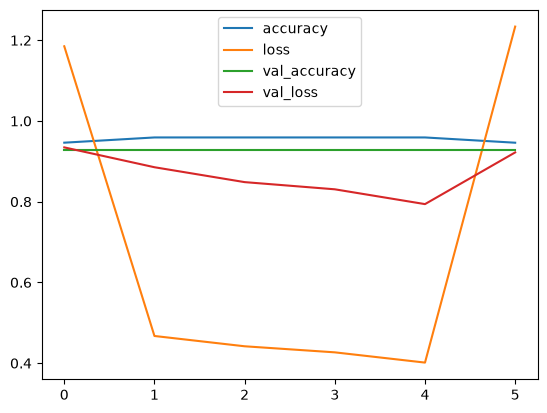

In [57]:
# csv 파일 로드 후 df으로 시각화
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train_log.csv')
df = df.drop(columns=['epoch']).plot()  # epoch 제외한 나머지 시각화
plt.show()

In [58]:
# 모델 저장
decoder_teacher_forcing_model.save('decoder_teacher_forcing_model.keras')

In [59]:
# 모델 로드
from tensorflow.keras.models import load_model
decoder_teacher_forcing_model = load_model('decoder_teacher_forcing_model.keras')
decoder_teacher_forcing_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 101)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 89)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 101, 100)  │    320,100 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 89, 100)   │  1,000,100 │ input_layer_12[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 512),     │  1,255,424 │ embedding_2[0][0] │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 89, 512), │  1,255,424 │ embedding_3[0][0… │
│                     │ (None, 512),      │            │ lstm_2[0][1],     │
│                     │ (None, 512)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 89, 10001) │  5,130,513 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,884,685 (102.56 MB)

 Trainable params: 8,961,561 (34.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,923,124 (68.37 MB)

In [60]:
# 추론 모델 : 한 토큰씩 생성하는 추론모델
decoder_hidden_state = layers.Input(shape=(LATENT_DIM,))  # 이전 시점 H(hidden state)값
decoder_cell_state = layers.Input(shape=(LATENT_DIM,))  # 이전 시점 C(cell state)값
decoder_states_inputs = [decoder_hidden_state, decoder_cell_state]  # (h, c) 상태 묶어 디코더 입력

decoder_single_input = layers.Input(shape=(1, ))  # 추론 시 한 개의 토큰(ID)씩만 입력 (B, 1)
x = ko_embedding_layer(decoder_single_input)  # (배치B, 1) -> (B, 1, EMBEDDING_DIM)

x, h, c = decoder_lstm(x, initial_state=decoder_states_inputs)  # 입력 토큰 + 이전상태 (h, c)로 다음상태 ㄱ
decoder_states = [h, c]  # 다음 스텝에 넘길 상태 (h, c) 저장

decoder_outputs_ = decoder_dense(x)  # (B, 1, kor_num_word+1) 다음 단어 확률 분포 출력

# 추론용 디코더 모델 (한 스텝)
decoder_inference_model = models.Model(
    inputs = [decoder_single_input] + decoder_states_inputs,  # 입력 : 현재 토큰 + 이전 상태(h, c)
    outputs = [decoder_outputs_] + decoder_states  # 출력 : 단어 분포 + 다음 상태(h, c)
)

decoder_inference_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 100)    │  1,000,100 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 1, 512),  │  1,255,424 │ embedding_3[1][0… │
│                     │ (None, 512),      │            │ input_layer_13[0… │
│                     │ (None, 512)]      │            │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 10001)  │  5,130,513 │ lstm_3[1][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,386,037 (28.18 MB)

 Trainable params: 7,386,037 (28.18 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# 번역함수 : 입력 영어 시퀀스를 인코더로 state로 변환 후, <sos>부터 시작해서 한 단어씩 생성하는 번역 함수
def translate(input_seq):
    encoder_states_value = encoder_model.predict(input_seq)  # 인코더에서 초기 상태(h, c) 추출
    decoder_states_value = encoder_states_value  # 디코더 초기 상태로 설정

    sos_index = kor_tokenizer.word_index['<sos>']  # 시작토큰 ID
    eos_index = kor_tokenizer.word_index['<eos>']  # 종료토큰 ID

    target_seq = np.zeros((1, 1))  # 디코더 입력(현재 토큰) 자리(B=1, 길이=1)
    target_seq[0, 0] = sos_index  # 첫 입력 토큰은 <sos>토큰으로 세팅

    output_sentences = []  # 생성된 단어(토큰)들을 담을 리스트

    for _ in range(kor_max_len):  # 최대 길이는 한글 토큰 길이로 설정
        output_tokens, h, c = decoder_inference_model.predict(
            # (현재 토큰 + 이전 state)로 다음 토큰 분포와 state 예측
            [target_seq] + decoder_states_value
        )

        pred_proba = output_tokens[0, 0, :]  # (1, 1, V) -> (V,)로 확률 벡터 추출
        pred_index = np.argmax(pred_proba)  # 가장 확률이 높은 단어 ID

        # 종료토큰 나오면 문장 생성 종료
        if pred_index == eos_index: 
            break

        # 패딩 토큰이 아닐 경우에만
        if pred_index > 0:
            word = kor_tokenizer.index_word[pred_index]  # 실제 단어로 역변환
            output_sentences.append(word)  # 문장 토큰 하나씩 리스트에 추가

        target_seq[0, 0] = pred_index  # 이번 예측 토큰은 다음 스텝 입력으로 갱신
        decoder_states_value = [h, c]  # 현재 state도 다음 스텝 입력으로 갱신

    return ' '.join(output_sentences)

In [62]:
def translate_eng2kor(eng_text):
    input_seq = eng_tokenizer.texts_to_sequences(eng_text)
    input_seq = pad_sequences(input_seq, maxlen=eng_max_len)
    return translate(input_seq)

eng_texts = [
    "My hair is black.", "French is interesting.", "I like bus.", "let's study", "I ate apple"
]

for eng_text in eng_texts:
    kor_text = translate_eng2kor([eng_text])
    display(eng_text, kor_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


KeyError: '<sos>'